**German Credit Dataset**

# 01 - Exploratory Data Analysis

**Objectives**
- Understand the context and the potential of the dataset
- Assess data quality, including missing values, outliers, and undocumented categories
- Analyze feature-target dependencies

In [168]:
import math
import string

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import mutual_info_classif

## 1. Load Data

**Source:** https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data

In [169]:
file_path = '../data/raw/german.data'
df = pd.read_csv(file_path, sep=r'\s+', header=None)

## 2. EDA

### 2.1. Dataset Description

In [170]:
print(f"Dataset shape: {df.shape}")
print(f"Dataset columns: {df.columns}")

Dataset shape: (1000, 21)
Dataset columns: Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20],
      dtype='int64')


In [171]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       1000 non-null   str  
 1   1       1000 non-null   int64
 2   2       1000 non-null   str  
 3   3       1000 non-null   str  
 4   4       1000 non-null   int64
 5   5       1000 non-null   str  
 6   6       1000 non-null   str  
 7   7       1000 non-null   int64
 8   8       1000 non-null   str  
 9   9       1000 non-null   str  
 10  10      1000 non-null   int64
 11  11      1000 non-null   str  
 12  12      1000 non-null   int64
 13  13      1000 non-null   str  
 14  14      1000 non-null   str  
 15  15      1000 non-null   int64
 16  16      1000 non-null   str  
 17  17      1000 non-null   int64
 18  18      1000 non-null   str  
 19  19      1000 non-null   str  
 20  20      1000 non-null   int64
dtypes: int64(8), str(13)
memory usage: 164.2 KB


In [172]:
df.head(20)

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2
5,A14,36,A32,A46,9055,A65,A73,2,A93,A101,...,A124,35,A143,A153,1,A172,2,A192,A201,1
6,A14,24,A32,A42,2835,A63,A75,3,A93,A101,...,A122,53,A143,A152,1,A173,1,A191,A201,1
7,A12,36,A32,A41,6948,A61,A73,2,A93,A101,...,A123,35,A143,A151,1,A174,1,A192,A201,1
8,A14,12,A32,A43,3059,A64,A74,2,A91,A101,...,A121,61,A143,A152,1,A172,1,A191,A201,1
9,A12,30,A34,A40,5234,A61,A71,4,A94,A101,...,A123,28,A143,A152,2,A174,1,A191,A201,2


Identifying potential categorical features:

In [173]:
summary = []

for col in df.columns:
    uniques = df[col].unique()
    n_unique = len(uniques)

    if n_unique > 5:
        example_values = list(uniques[:5]) + ["..."]
    else:
        example_values = list(uniques)

    summary.append({
        "column": col,
        "dtype": df[col].dtype,
        "unique_values": n_unique,
        "example_values": example_values
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

    column  dtype  unique_values                       example_values
0        0    str              4                 [A11, A12, A14, A13]
1        1  int64             33             [6, 48, 12, 42, 24, ...]
2        2    str              5            [A34, A32, A33, A30, A31]
3        3    str             10       [A43, A46, A42, A40, A41, ...]
4        4  int64            921  [1169, 5951, 2096, 7882, 4870, ...]
5        5    str              5            [A65, A61, A63, A64, A62]
6        6    str              5            [A75, A73, A74, A71, A72]
7        7  int64              4                         [4, 2, 3, 1]
8        8    str              4                 [A93, A92, A91, A94]
9        9    str              3                   [A101, A103, A102]
10      10  int64              4                         [4, 2, 3, 1]
11      11    str              4             [A121, A122, A124, A123]
12      12  int64             53            [67, 22, 49, 45, 53, ...]
13      13    str   

#### Dataset's descriptive characteristics

The following description is based on the information provided in the original source where this dataset is published. The dataset corresponds to a credit risk classification problem (commonly known as the *German Credit Dataset*) and contains 20 input attributes and 1 target variable.

- 1,000 rows
- 21 columns (including the target column)
- No missing values

**Monetary values are expressed in DM (Deutsche Mark)*


| Variable Name | Role   | Type        | Description                                              | Units  |
|---------------|--------|-------------|----------------------------------------------------------|--------|
| Attribute1    | Feature| Categorical | Status of existing checking account                      |        |
| Attribute2    | Feature| Integer     | Duration                                                 | months |
| Attribute3    | Feature| Categorical | Credit history                                           |        |
| Attribute4    | Feature| Categorical | Purpose                                                  |        |
| Attribute5    | Feature| Integer     | Credit amount                                            |        |
| Attribute6    | Feature| Categorical | Savings account / bonds                                  |        |
| Attribute7    | Feature| Categorical | Present employment since                                 |        |
| Attribute8    | Feature| Integer     | Installment rate in percentage of disposable income      |        |
| Attribute9    | Feature| Categorical | Personal status and sex                                  |        |
| Attribute10   | Feature| Categorical | Other debtors / guarantors                               |        |
| Attribute11   | Feature| Integer     | Present residence since                                  |        |
| Attribute12   | Feature| Categorical | Property                                                 |        |
| Attribute13   | Feature| Integer     | Age                                                      | years  |
| Attribute14   | Feature| Categorical | Other installment plans                                  |        |
| Attribute15   | Feature| Categorical | Housing                                                  |        |
| Attribute16   | Feature| Integer     | Number of existing credits at this bank                  |        |
| Attribute17   | Feature| Categorical | Job                                                      |        |
| Attribute18   | Feature| Integer     | Number of people being liable to provide maintenance for |        |
| Attribute19   | Feature| Binary      | Telephone                                                |        |
| Attribute20   | Feature| Binary      | Foreign worker                                           |        |
| class         | Target | Binary      | 1 = Good, 2 = Bad                                        |        |

**Attribute 1 — Status of Existing Checking Account (Categorical)**

- A11: balance < 0 DM  
- A12: 0 ≤ balance < 200 DM  
- A13: balance ≥ 200 DM or salary assigned for at least 1 year  
- A14: no checking account  


**Attribute 2 — Duration (Numerical)**

- Duration of the credit in months.


**Attribute 3 — Credit History (Categorical)**

- A30: no credits taken / all credits paid back duly  
- A31: all credits at this bank paid back duly  
- A32: existing credits paid back duly until now  
- A33: delay in paying off in the past  
- A34: critical account / other credits existing (not at this bank)  


**Attribute 4 — Purpose (Categorical)**

- A40: car (new)  
- A41: car (used)  
- A42: furniture / equipment  
- A43: radio / television  
- A44: domestic appliances  
- A45: repairs  
- A46: education  
- A47: vacation (not used in practice)  
- A48: retraining  
- A49: business  
- A410: others  


**Attribute 5 — Credit Amount (Numerical)**

- Amount of credit requested (in DM).


**Attribute 6 — Savings Account / Bonds (Categorical)**

- A61: balance < 100 DM  
- A62: 100 ≤ balance < 500 DM  
- A63: 500 ≤ balance < 1000 DM  
- A64: balance ≥ 1000 DM  
- A65: unknown / no savings account  


**Attribute 7 — Present Employment Since (Categorical)**

- A71: unemployed  
- A72: < 1 year  
- A73: 1 to 4 years  
- A74: 4 to 7 years  
- A75: ≥ 7 years  


**Attribute 8 — Installment Rate (Numerical)**

- Installment rate as a percentage of disposable income.

*Although described as numerical in the original source, it only takes the discrete values 1, 2, 3 and 4


**Attribute 9 — Personal Status and Sex (Categorical)**

- A91: male, divorced/separated  
- A92: female, divorced/separated/married  
- A93: male, single  
- A94: male, married/widowed  
- A95: female, single  


**Attribute 10 — Other Debtors / Guarantors (Categorical)**

- A101: none  
- A102: co-applicant  
- A103: guarantor 


**Attribute 11 — Present Residence Since (Numerical)**

- Number of years at the current residence.

*Although described as numerical in the original source, it only takes the discrete values 1, 2, 3 and 4


**Attribute 12 — Property (Categorical)**

- A121: real estate  
- A122: building society savings agreement / life insurance  
- A123: car or other property (not in Attribute 6)  
- A124: unknown / no property  


**Attribute 13 — Age (Numerical)**

- Age in years.


**Attribute 14 — Other Installment Plans (Categorical)**

- A141: bank  
- A142: stores  
- A143: none  



**Attribute 15 — Housing (Categorical)**

- A151: rent  
- A152: own  
- A153: for free  


**Attribute 16 — Number of Existing Credits at This Bank (Numerical)**

- Total number of credits currently held at this bank.

*Although described as numerical in the original source, it only takes the discrete values 1, 2, 3 and 4


**Attribute 17 — Job (Categorical)**

- A171: unemployed / unskilled (non-resident)  
- A172: unskilled (resident)  
- A173: skilled employee / official  
- A174: management / self-employed / highly qualified employee / officer  


**Attribute 18 — Number of People Liable for Maintenance (Numerical)**

- Number of dependents financially supported by the applicant.

*Although described as numerical in the original source, it only takes the discrete values 1 and 2


**Attribute 19 — Telephone (Categorical)**

- A191: none  
- A192: yes, registered under the customer’s name  


**Attribute 20 — Foreign Worker (Categorical)**

- A201: yes  
- A202: no  


**Target Variable — Credit Risk**

The target variable indicates the credit risk of the applicant:

- 1: Good credit risk  
- 2: Bad credit risk  

For convenience and standardization purposes, a copy of the original dataset is created below with renamed fields. Additionally, a mapping of categorical data labels is created and organized by feature name, in order to facilitate the plotting of charts with meaningful labels:

In [174]:
df_standard = df.copy()

In [175]:
# renaming columns
df_standard = df_standard.rename(columns={
    0:  "checking_account_status",
    1:  "duration_months",
    2:  "credit_history",
    3:  "purpose",
    4:  "credit_amount",
    5:  "savings_account_status",
    6:  "employment_status",
    7:  "installment_rate",
    8:  "marriage_status_sex",
    9:  "guarantors",
    10: "residence_duration",
    11: "property",
    12: "age",
    13: "other_debts",
    14: "housing",
    15: "existing_credits_count",
    16: "job",
    17: "dependents",
    18: "own_telephone?",
    19: "foreign_worker?",
    20: "good_client?"   # target variable
})

In [176]:
# Mapping categorical variables to integers
category_map_numeric = {
    "checking_account_status": {
        "A11": 1,
        "A12": 2,
        "A13": 3,
        "A14": 4
    },

    "credit_history": {
        "A30": 1,
        "A31": 2,
        "A32": 3,
        "A33": 4,
        "A34": 5
    },

    "purpose": {
        "A40": 1,
        "A41": 2,
        "A42": 3,
        "A43": 4,
        "A44": 5,
        "A45": 6,
        "A46": 7,
        "A47": 8,
        "A48": 9,
        "A49": 10,
        "A410": 11
    },

    "savings_account_status": {
        "A61": 1,
        "A62": 2,
        "A63": 3,
        "A64": 4,
        "A65": 5
    },

    "employment_status": {
        "A71": 1,
        "A72": 2,
        "A73": 3,
        "A74": 4,
        "A75": 5
    },

    "marriage_status_sex": {
        "A91": 1,
        "A92": 2,
        "A93": 3,
        "A94": 4,
        "A95": 5
    },

    "guarantors": {
        "A101": 1,
        "A102": 2,
        "A103": 3
    },

    "property": {
        "A121": 1,
        "A122": 2,
        "A123": 3,
        "A124": 4
    },

    "other_debts": {
        "A141": 1,
        "A142": 2,
        "A143": 3
    },

    "housing": {
        "A151": 1,
        "A152": 2,
        "A153": 3
    },

    "job": {
        "A171": 1,
        "A172": 2,
        "A173": 3,
        "A174": 4
    },

    "own_telephone?": {
        "A191": 0,
        "A192": 1
    },

    "foreign_worker?": {
        "A201": 1,
        "A202": 0
    },

    "good_client?": {
        1: 1,
        2: 0
    },

    "installment_rate": {
        1: 1,
        2: 2,
        3: 3,
        4: 4
    },

    "residence_duration": {
        1: 1,
        2: 2,
        3: 3,
        4: 4
    },

    "existing_credits_count": {
        1: 1,
        2: 2,
        3: 3,
        4: 4
    },

    "dependents": {
        1: 1,
        2: 2
    }
}

for col, mapping in category_map_numeric.items():
    df_standard[col] = df_standard[col].map(mapping)

In [177]:
# mapping categorical data labels
category_map = {
    "checking_account_status": {
        1: "< 0 DM",
        2: "0 to < 200 DM",
        3: ">= 200 DM",
        4: "no checking account"
    },

    "credit_history": {
        1: "no credits/all paid duly",
        2: "all credits paid duly",
        3: "existing credits paid duly",
        4: "past payment delays",
        5: "critical account/other credits"
    },

    "purpose": {
        1: "new car",
        2: "used car",
        3: "furniture/equipment",
        4: "radio/TV",
        5: "domestic appliances",
        6: "repairs",
        7: "education",
        8: "vacation",
        9: "retraining",
        10: "business",
        11: "other"
    },

    "savings_account_status": {
        1: "< 100 DM",
        2: "100 to < 500 DM",
        3: "500 to < 1000 DM",
        4: ">= 1000 DM",
        5: "unknown / none"
    },

    "employment_status": {
        1: "unemployed",
        2: "< 1 year",
        3: "1 to 4 years",
        4: "4 to 7 years",
        5: ">= 7 years"
    },

    "marriage_status_sex": {
        1: "male divorced/separated",
        2: "female divorced/separated/married",
        3: "male single",
        4: "male married/widowed",
        5: "female single"
    },

    "guarantors": {
        1: "none",
        2: "co-applicant",
        3: "guarantor"
    },

    "property": {
        1: "real estate",
        2: "savings/life insurance",
        3: "car or other property",
        4: "unknown/none"
    },

    "other_debts": {
        1: "bank",
        2: "stores",
        3: "none"
    },

    "housing": {
        1: "rent",
        2: "own",
        3: "free"
    },

    "job": {
        1: "unemployed/unskilled (non-resident)",
        2: "unskilled (resident)",
        3: "skilled employee",
        4: "management/self-employed / highly qualified"
    },

    "own_telephone?": {
        1: "yes",
        0: "no"
    },

    "foreign_worker?": {
        1: "yes",
        0: "no"
    },

    "good_client?": {
        1: "yes",
        0: "no"
    },

    "installment_rate": {
        1: "1",
        2: "2",
        3: "3",
        4: "4"
    },

    "residence_duration": {
        1: "1",
        2: "2",
        3: "3",
        4: "4"
    },

    "existing_credits_count": {
        1: "1",
        2: "2",
        3: "3",
        4: "4"
    },

    "dependents": {
        1: "1",
        2: "2"
    }
}

In [178]:
df_standard.head(20)

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_status,employment_status,installment_rate,marriage_status_sex,guarantors,...,property,age,other_debts,housing,existing_credits_count,job,dependents,own_telephone?,foreign_worker?,good_client?
0,1,6,5,4,1169,5,5,4,3,1,...,1,67,3,2,2,3,1,1,1,1
1,2,48,3,4,5951,1,3,2,2,1,...,1,22,3,2,1,3,1,0,1,0
2,4,12,5,7,2096,1,4,2,3,1,...,1,49,3,2,1,2,2,0,1,1
3,1,42,3,3,7882,1,4,2,3,3,...,2,45,3,3,1,3,2,0,1,1
4,1,24,4,1,4870,1,3,3,3,1,...,4,53,3,3,2,3,2,0,1,0
5,4,36,3,7,9055,5,3,2,3,1,...,4,35,3,3,1,2,2,1,1,1
6,4,24,3,3,2835,3,5,3,3,1,...,2,53,3,2,1,3,1,0,1,1
7,2,36,3,2,6948,1,3,2,3,1,...,3,35,3,1,1,4,1,1,1,1
8,4,12,3,4,3059,4,4,2,1,1,...,1,61,3,2,1,2,1,0,1,1
9,2,30,5,1,5234,1,1,4,4,1,...,3,28,3,2,2,4,1,0,1,0


In [179]:
# Numerical columns
numerical_cols = ['duration_months', 'credit_amount', 'age']

# Categorical and binary columns (excluding target variable)
categorical_cols = ['checking_account_status', 'credit_history', 'purpose', 'savings_account_status', 'employment_status', 'marriage_status_sex', 'guarantors', 'property', 'other_debts', 'housing', 'job', 'own_telephone?', 'foreign_worker?', 'installment_rate', 'existing_credits_count', 'residence_duration', 'dependents']

TARGET = "good_client?"

### 2.3. Exploratory Visualizations

#### 2.3.1. Data Distribution

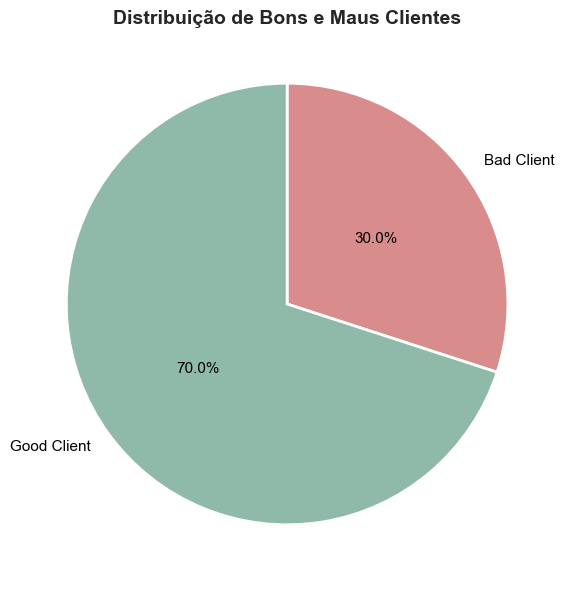

In [180]:
counts = df_standard[TARGET].value_counts().sort_index()
labels = ['Bad Client', 'Good Client']

colors = ['#D98C8C', '#8FB9A8'] 

fig, ax = plt.subplots(figsize=(6.5, 6))

wedges, texts, autotexts = ax.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct=lambda pct: f'{pct:.1f}%',
    startangle=90,
    counterclock=False,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops=dict(color='black', fontsize=11),
    pctdistance=0.5
)

ax.set_title(
    'Distribuição de Bons e Maus Clientes',
    fontsize=14,
    fontweight='bold',
    pad=0.0 
)

plt.tight_layout()
plt.show()

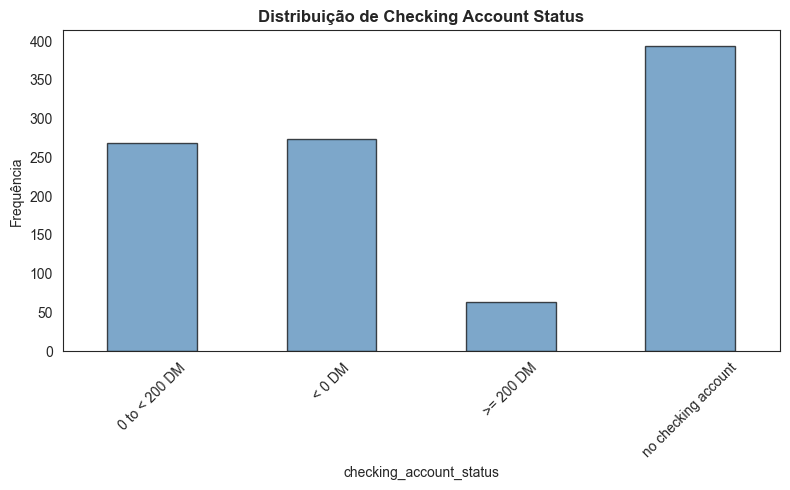

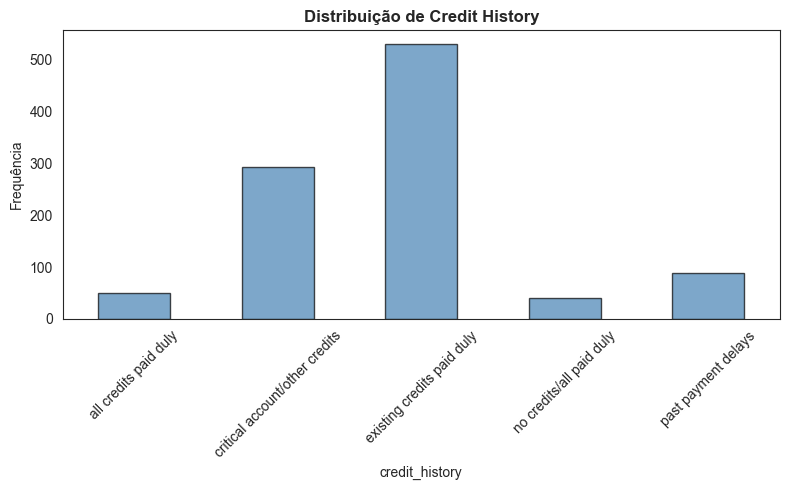

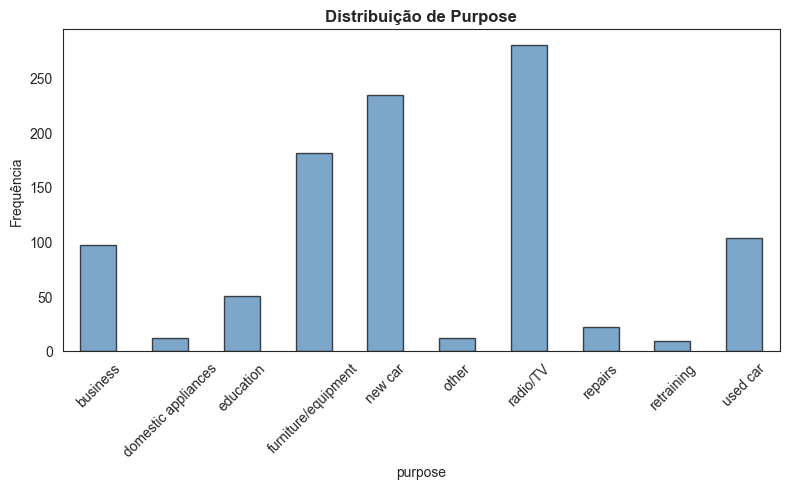

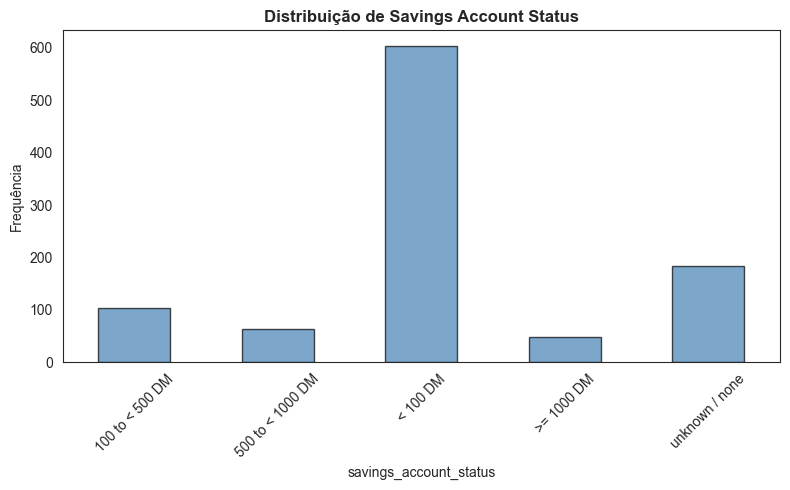

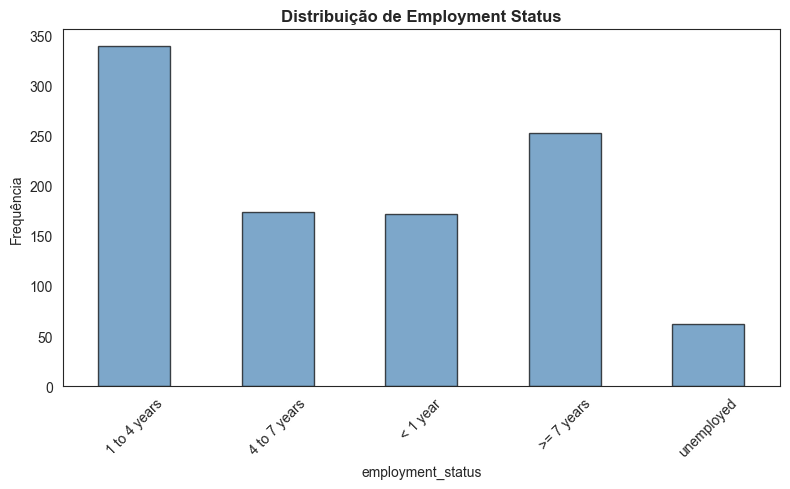

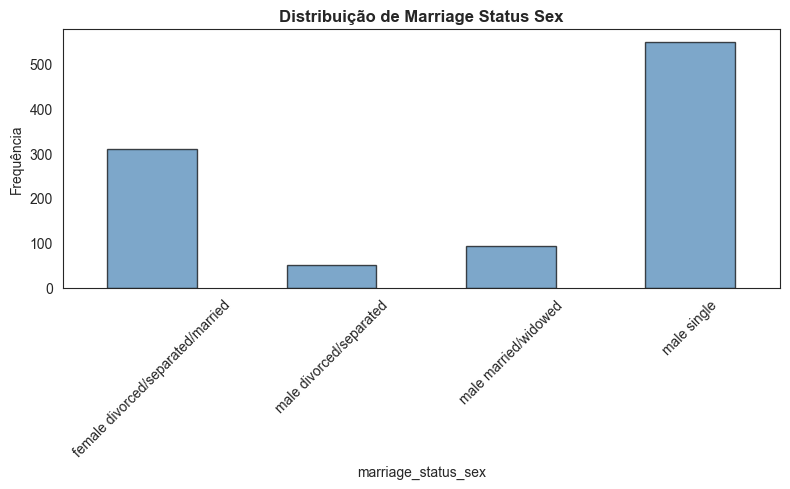

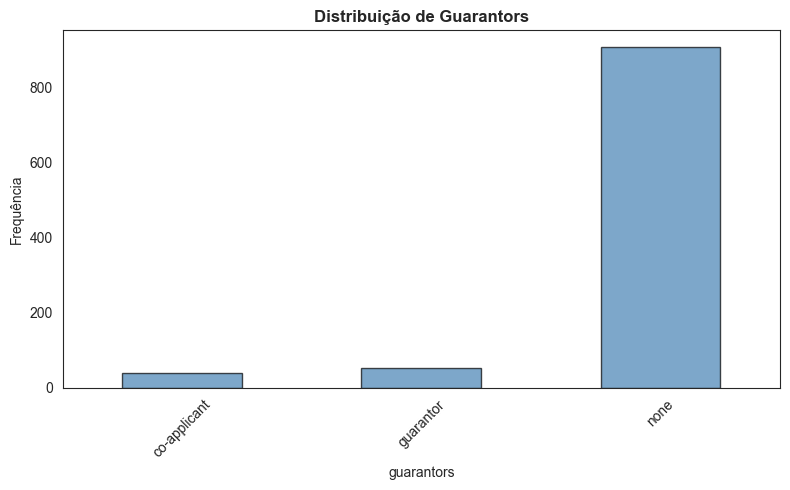

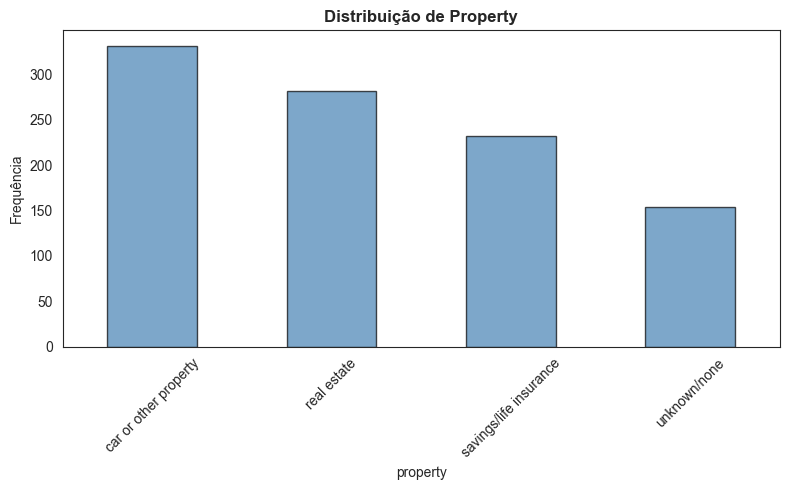

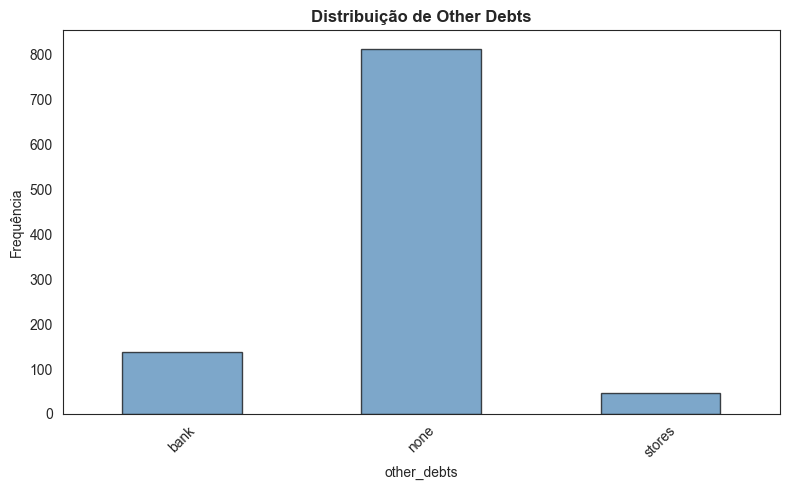

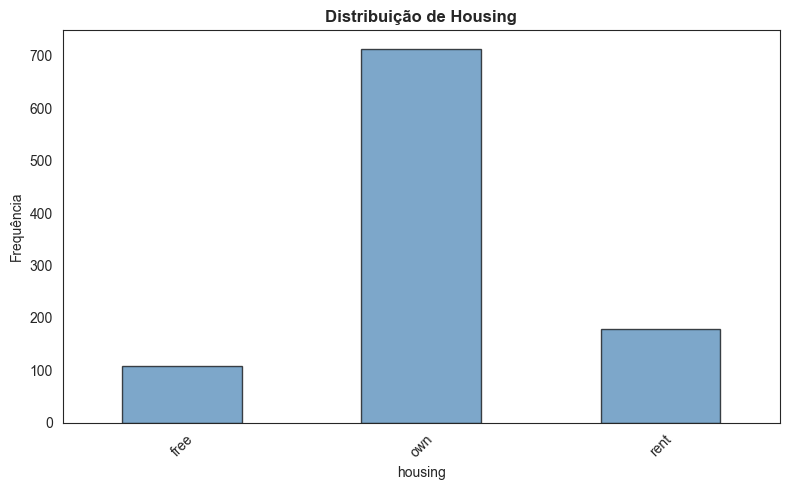

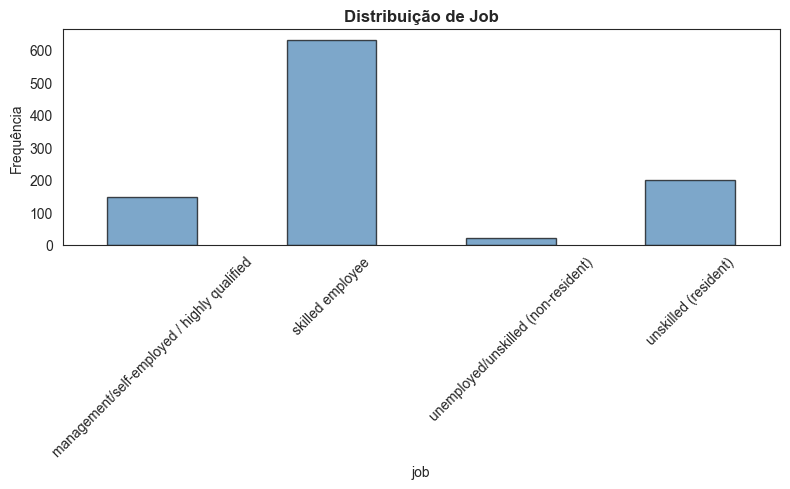

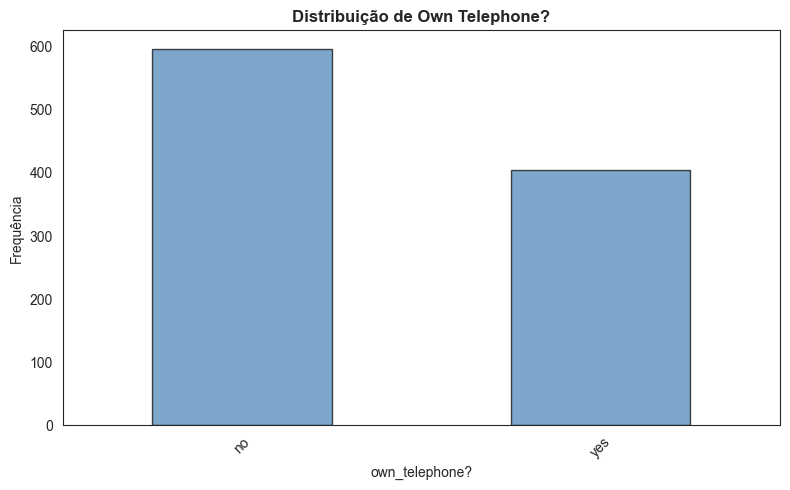

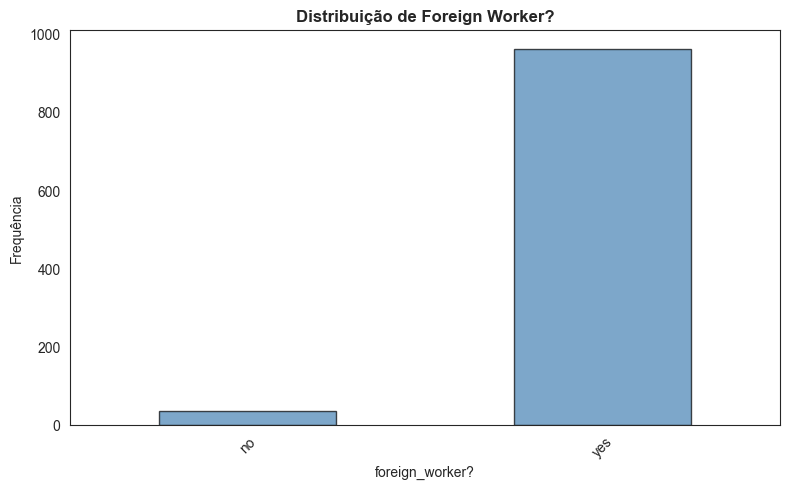

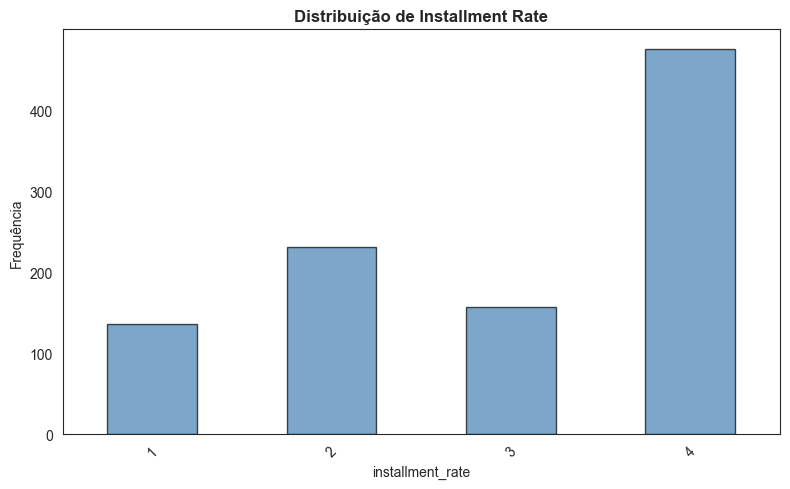

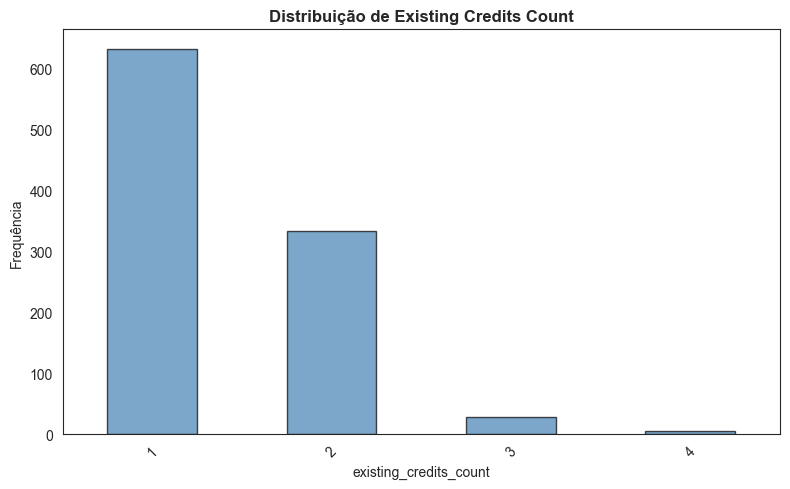

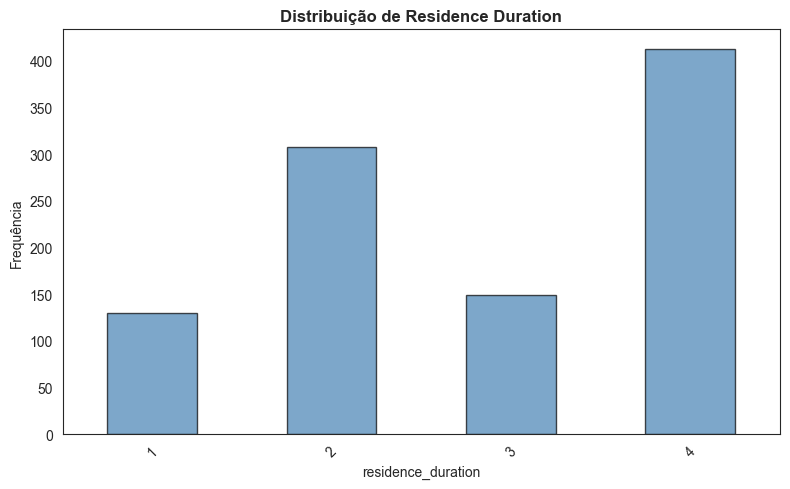

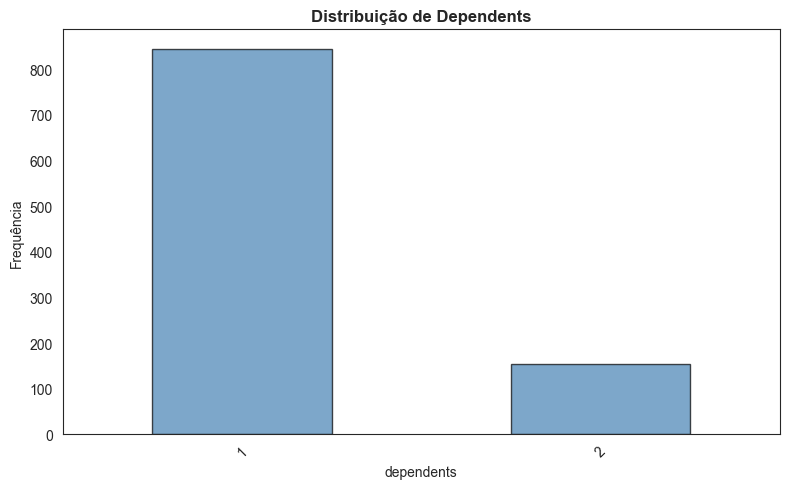

In [181]:
# Plotting distribution of categorical variables
for col in categorical_cols:
    plt.figure(figsize=(8, 5))

    mapped = df_standard[col].map(category_map[col])
    mapped.value_counts().sort_index().plot(kind="bar", color="steelblue", edgecolor='black', alpha=0.7)

    title = col.replace("_", " ").title()
    plt.title(f"Distribuição de {title}", fontweight="bold")
    plt.ylabel("Frequência")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

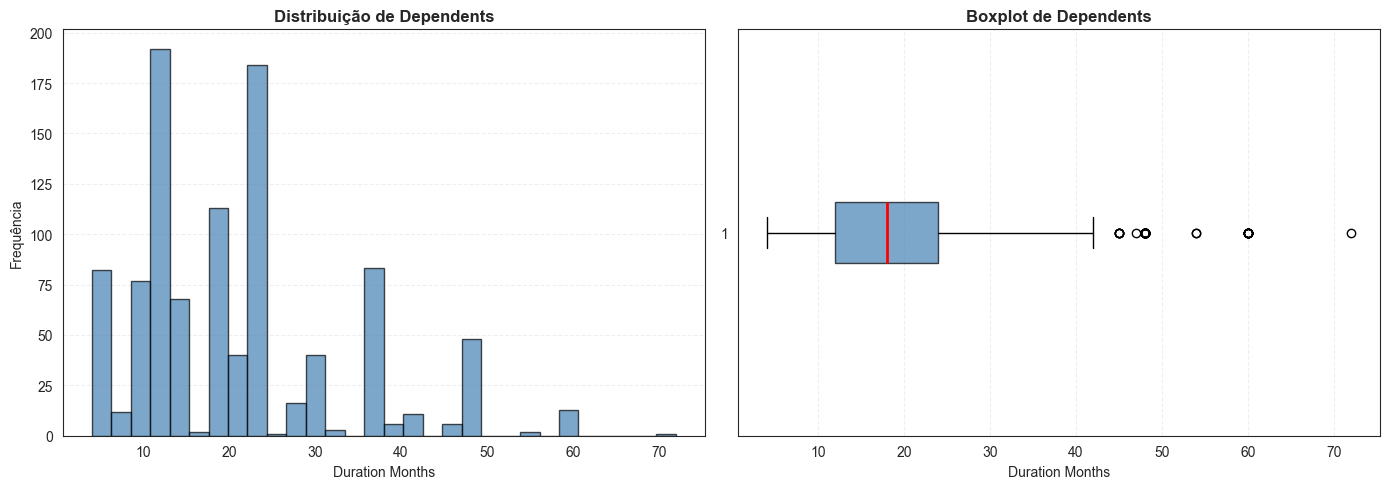

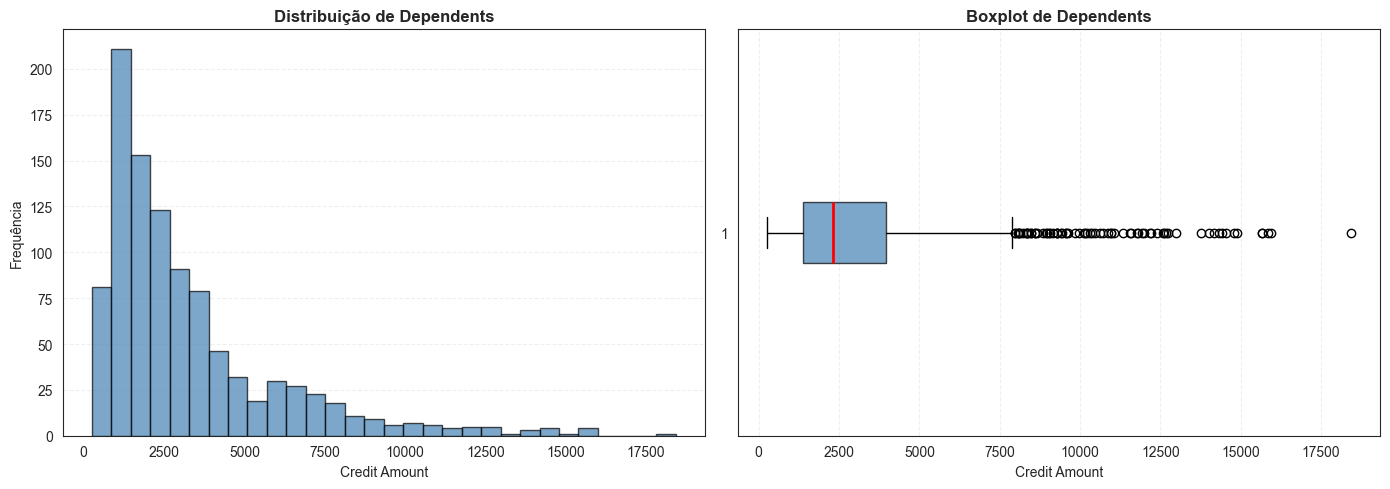

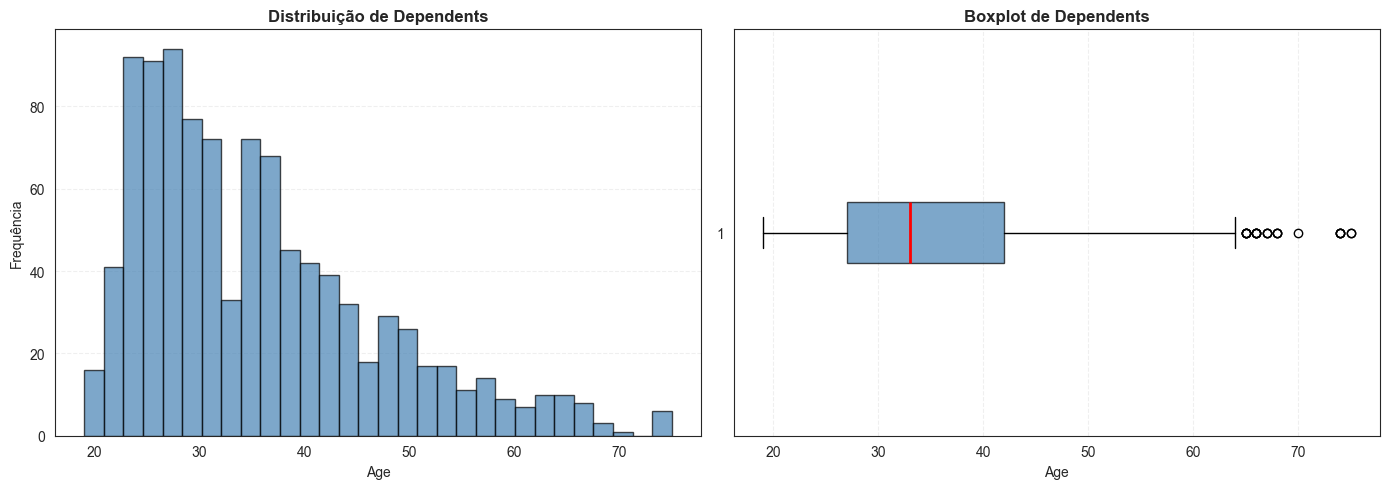

In [182]:
# Plotting distribution of numerical variables
for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(df_standard[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_title(f"Distribuição de {title}", fontweight="bold")
    axes[0].set_xlabel(col.replace("_", " ").title())
    axes[0].set_ylabel('Frequência')
    axes[0].grid(axis='y', linestyle='--', alpha=0.3)
    
    # Boxplot
    axes[1].boxplot(df_standard[col], vert=False, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[1].set_title(f"Boxplot de {title}", fontweight="bold")
    axes[1].set_xlabel(col.replace("_", " ").title())
    axes[1].grid(axis='x', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

#### 2.3.2. Bad Client Rate Analysis Across Features

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


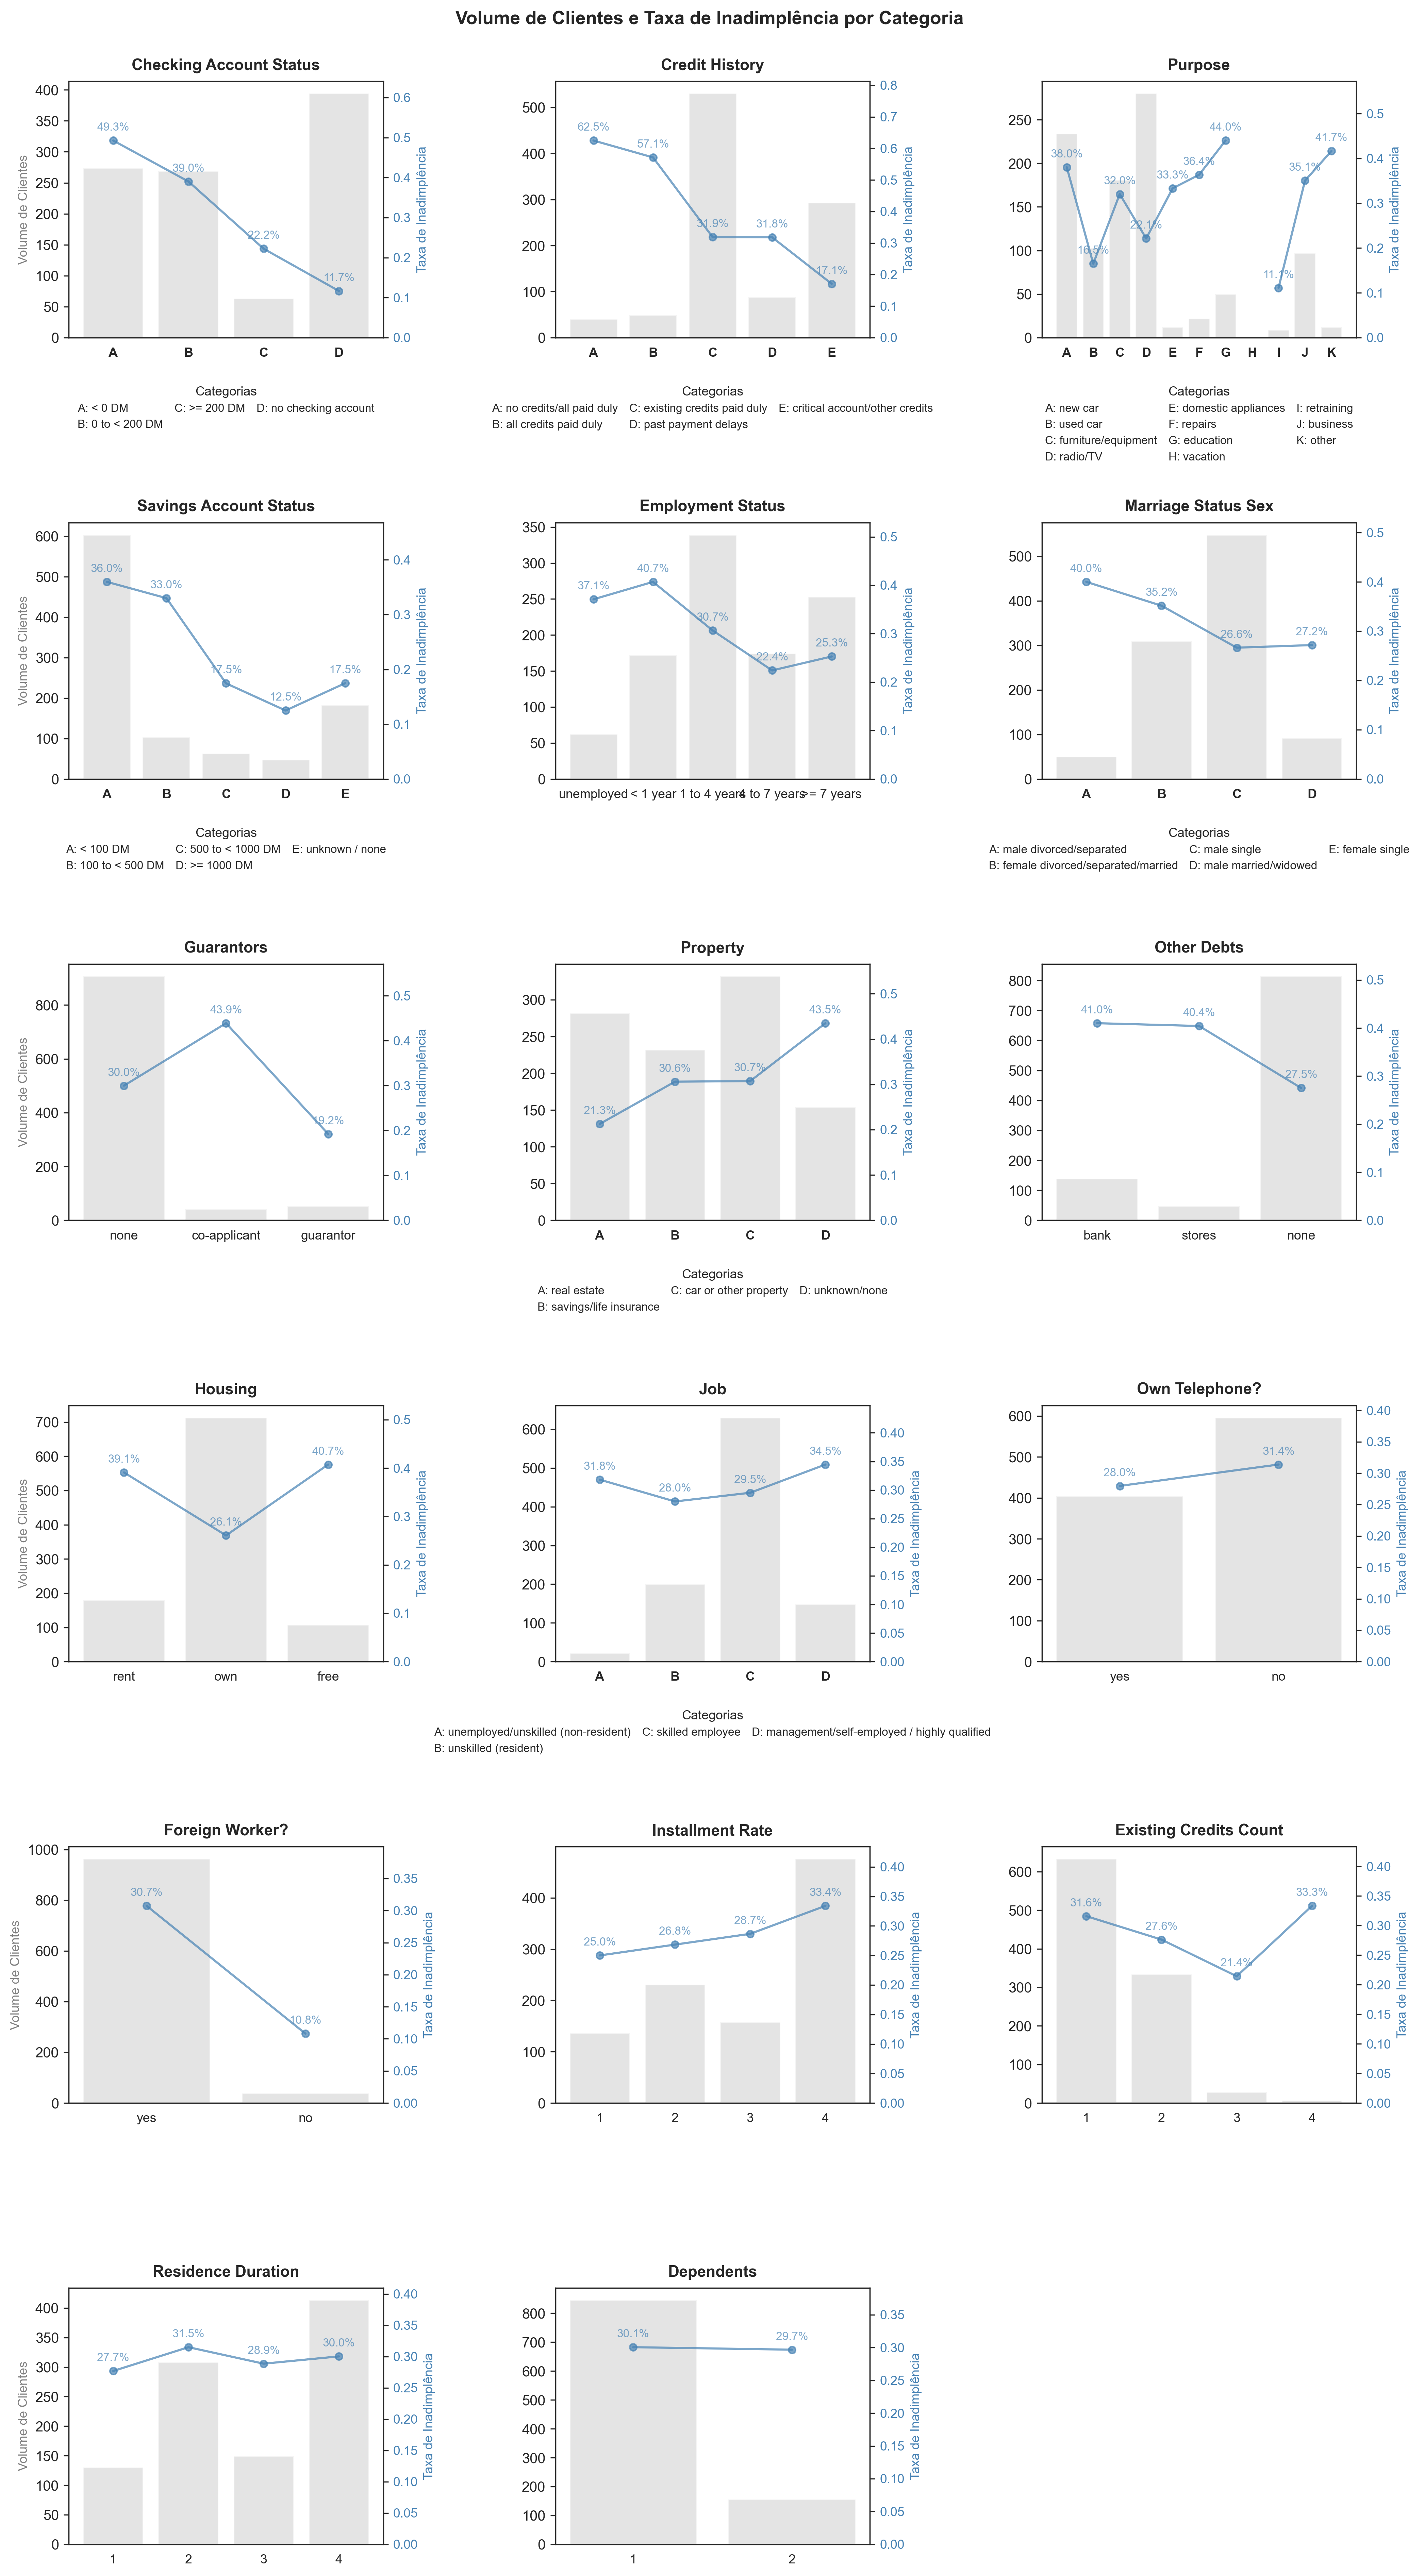

In [183]:
# Plotting client volume and bad client rate by categorical variable
n_cols = 3
n_rows = math.ceil(len(categorical_cols) / n_cols)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(14, 4.2 * n_rows),
    dpi=300
)
axes = axes.flatten()

CHAR_LIMIT = 15

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    data = df_standard.copy()
    data["label"] = data[col].map(category_map[col])

    x_order = list(category_map[col].values())

    bad_rate = (
        data.groupby("label")["good_client?"]
        .apply(lambda x: (1 - x).mean())
        .reindex(x_order)
    )

    sns.countplot(
        data=data,
        x="label",
        order=x_order,
        color="lightgray",
        alpha=0.6,
        ax=ax
    )

    ax.set_xlabel("")
    ax.set_ylabel("Volume de Clientes" if i % n_cols == 0 else "", color="gray", fontsize=9)
    ax.set_xticks(range(len(x_order)))

    if max(map(len, x_order)) > CHAR_LIMIT:
        labels = list(string.ascii_uppercase[:len(x_order)])
        ax.set_xticklabels(labels, fontweight="bold", fontsize=9)

        legend_labels = [
            f"{letter}: {category}"
            for letter, category in zip(labels, x_order)
        ]

        handles = [mpatches.Patch(alpha=0) for _ in legend_labels]

        ax.legend(
            handles=handles,
            labels=legend_labels,
            title="Categorias",
            loc="upper center",
            bbox_to_anchor=(0.5, -0.15),
            ncol=3,
            fontsize=8,
            title_fontsize=9,
            frameon=False,
            handlelength=0,
            handletextpad=0,
            columnspacing=1
        )

    else:
        ax.set_xticklabels(x_order, fontsize=9)

    # ax -> bars
    # ax2 -> line
    ax2 = ax.twinx()
    x = range(len(x_order))

    ax2.plot(x, bad_rate, color="steelblue", alpha=0.7, marker="o", linewidth=1.5, markersize=5)
    ax2.set_ylabel( "Taxa de Inadimplência" , color="steelblue", fontsize=9)
    ax2.tick_params(axis="y", labelcolor="steelblue", labelsize=9)

    max_y = bad_rate.max()
    ax2.set_ylim(0, max_y * 1.3)

    for j, value in enumerate(bad_rate):
        ax2.text(
            j,
            value + max_y * 0.05,
            f"{value:.1%}",
            color="steelblue",
            alpha=0.7,
            ha="center",
            fontsize=8
        )

    ax.set_title(
        col.replace("_", " ").title(),
        fontsize=11,
        fontweight="bold",
        pad=8
    )

# Remove empty graphs 
for ax in axes[len(categorical_cols):]:
    fig.delaxes(ax)

fig.suptitle(
    "Volume de Clientes e Taxa de Inadimplência por Categoria",
    fontsize=13,
    fontweight="bold",
    y=1
)

plt.tight_layout(w_pad=0.5, h_pad=2)
plt.show()

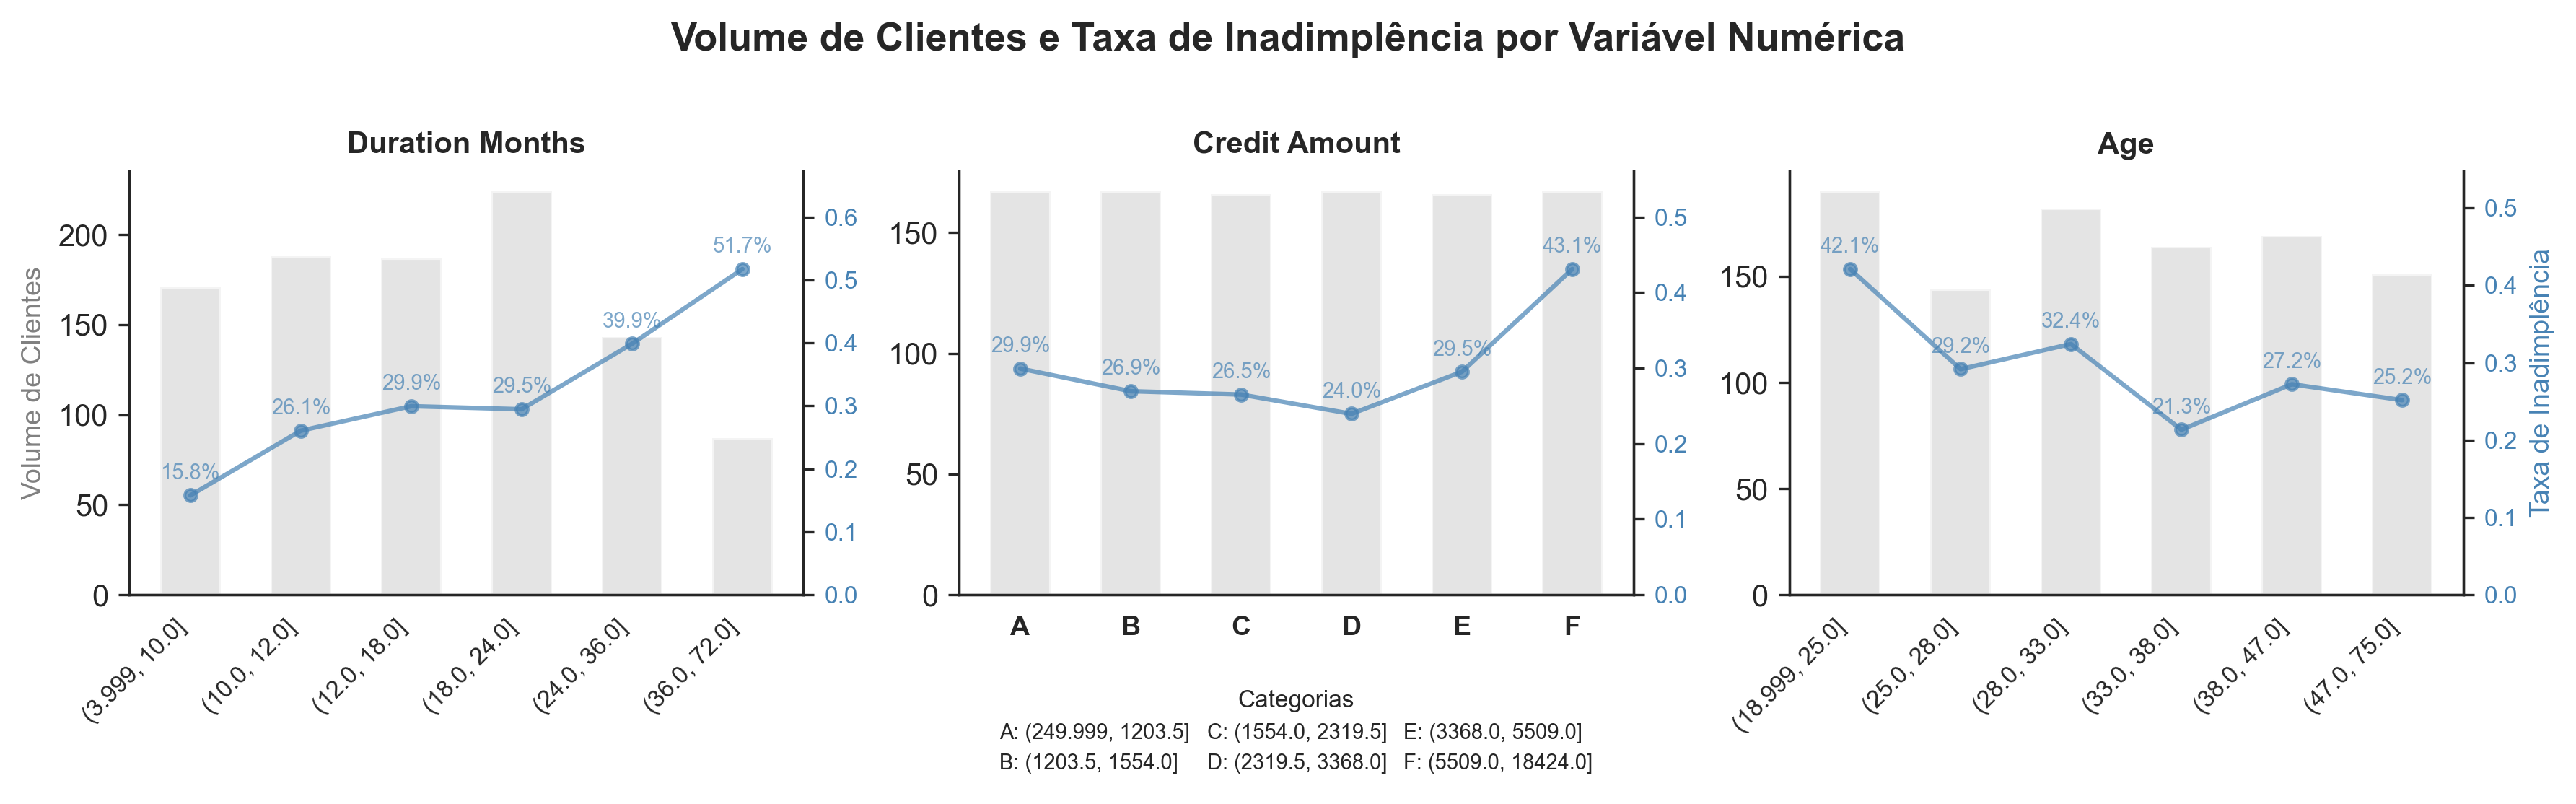

In [184]:
# Plotting client volume and bad client rate by numerical variable
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 3.8 * n_rows),
    dpi=300
)

axes = axes.flatten()

CHAR_LIMIT = 15

for i, col in enumerate(numerical_cols):

    ax = axes[i]
    data = df_standard.copy()
    s = data[col]

    n_unique = s.nunique()

    if n_unique <= 10:
        data["bin"] = pd.Categorical(s, ordered=True)
        x_order = sorted(s.unique())
    else:
        data["bin"] = pd.qcut(s, q=6, duplicates="drop")
        x_order = list(data["bin"].cat.categories)

    bad_rate = (
        data.groupby("bin", observed=False)["good_client?"]
        .apply(lambda x: (1 - x).mean())
        .reindex(x_order)
    )

    sns.countplot(
        data=data,
        x="bin",
        order=x_order,
        color="lightgray",
        alpha=0.6,
        width=0.55,
        ax=ax
    )

    ax.set_xlabel("")
    ax.set_ylabel(
        "Volume de Clientes" if i % n_cols == 0 else "",
        color="gray",
        fontsize=9
    )

    ax.set_xticks(range(len(x_order)))

    if max(map(lambda x: len(str(x)), x_order)) > CHAR_LIMIT:

        labels = list(string.ascii_uppercase[:len(x_order)])

        ax.set_xticklabels(
            labels,
            fontweight="bold",
            fontsize=9
        )

        legend_labels = [
            f"{letter}: {category}"
            for letter, category in zip(labels, x_order)
        ]

        handles = [
            mpatches.Patch(alpha=0)
            for _ in legend_labels
        ]

        ax.legend(
            handles=handles,
            labels=legend_labels,
            title="Categorias",
            loc="upper center",
            bbox_to_anchor=(0.5, -0.18),
            ncol=3,
            fontsize=7,
            title_fontsize=8,
            frameon=False,
            handlelength=0,
            handletextpad=0,
            columnspacing=0.8
        )

    else:
        ax.set_xticklabels(
            x_order,
            fontsize=8,
            rotation=45,
            ha="right"
        )

    ax2 = ax.twinx()

    x = range(len(x_order))

    ax2.plot(
        x,
        bad_rate,
        color="steelblue",
        alpha=0.7,
        marker="o",
        linewidth=1.5,
        markersize=4
    )

    ax2.set_ylabel(
        "Taxa de Inadimplência" if i % n_cols == n_cols - 1 else "",
        color="steelblue",
        fontsize=9
    )

    ax2.tick_params(
        axis="y",
        labelcolor="steelblue",
        labelsize=8
    )

    max_y = bad_rate.max()
    ax2.set_ylim(0, max_y * 1.3)

    for j, value in enumerate(bad_rate):
        ax2.text(
            j,
            value + max_y * 0.05,
            f"{value:.1%}",
            color="steelblue",
            alpha=0.7,
            ha="center",
            fontsize=7
        )

    ax.set_title(
        col.replace("_", " ").title(),
        fontsize=10,
        fontweight="bold",
        pad=6
    )

    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)


# Remove empty graphs 
for ax in axes[len(numerical_cols):]:
    fig.delaxes(ax)


fig.suptitle(
    "Volume de Clientes e Taxa de Inadimplência por Variável Numérica",
    fontsize=13,
    fontweight="bold",
    y=1.01
)

plt.tight_layout(
    w_pad=1.0,
    h_pad=2.0
)

plt.show()

## 3. Exporting Dataset

In [187]:
file_out_path = '../data/processed'

df_standard.to_csv(file_out_path + '/german_df_processed_1.csv', index=False)